In [1]:
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from prc1_state import State

In [2]:
# ============================================================

# Spatial geometry/constants
MICROTUBULE_LENGTH = 5000
SITE_SPACING = 8
MICROTUBULE_OFFSET = 0
SPRING_CONSTANT = 2
REST_LENGTH = 32
KBT = 4.1
MICROTUBULE_SEPARATION = 30
BASE_HOPPING_RATE = 1.0

# Fixed spatial rates
INIT_BIND = 0.002       # k01_site
K_DET_1 = 0.15          # k10_spatial

# Spatial simulation settings
TIMES_OBS = np.arange(0, 68 + 4, 4, dtype=float)
N_SPATIAL_REPS = 3
ENABLE_HOPPING = False
MAX_STEPS = 200_000

# Training dataset settings
N_GOOD = 300
MAX_ATTEMPTS = 3000
RANDOM_SEED = 123

# Spatial pair sampling ranges
K12_SITE_MIN, K12_SITE_MAX = 0.1, 20.0
K21_BASE_MIN, K21_BASE_MAX = 0.005, 1.0

# Population range filter after mapping
K12_POP_MIN, K12_POP_MAX = 1.0, 30.0
K21_POP_MIN, K21_POP_MAX = 0.02, 1.0

# Good-row filters
MIN_TOTAL_N1 = 10.0
MIN_TOTAL_N2 = 10.0

# This checks whether the simple capped map k12_site*m_hat is close
# to the actual spatial second-head hazard average.
# Set to np.inf if you do not want this filter.
K12_MAP_ERROR_MAX = 0.60

In [3]:
# ============================================================

def make_state(k12_site, k21_base):
    return State(
        MICROTUBULE_LENGTH,
        SITE_SPACING,
        MICROTUBULE_OFFSET,
        SPRING_CONSTANT,
        REST_LENGTH,
        KBT,
        MICROTUBULE_SEPARATION,
        INIT_BIND,
        K_DET_1,
        float(k12_site),
        float(k21_base),
        BASE_HOPPING_RATE,
        0.0,       # cooperativity_energy
        False,     # enable_initial_attach_cooperativity
        False,     # enable_second_head_attach_cooperativity
        False,     # enable_second_head_detach_cooperativity
    )


def count_second_head_targets_capped(prc1):
    """
    Count reachable opposite-side sites among closest-1, closest, closest+1.
    This is the report-style capped m_i <= 3 map.
    """
    closest = prc1.closest_index_on_other_side
    if closest is None:
        return 0

    state = prc1.state
    count = 0

    for offset in (-1, 0, 1):
        target = int(closest + offset)

        if target < 0 or target >= state.num_sites:
            continue

        if prc1.top_head_is_attached:
            if target in state.bottom_untaken_sites:
                count += 1

        elif prc1.bottom_head_is_attached:
            if target in state.top_untaken_sites:
                count += 1

    return min(count, 3)


def spatial_diagnostics(state):
    """
    Diagnostics at one time point.
    """
    doubly = list(state.doubly_attached_prc1)
    singly = list(state.top_attached_prc1) + list(state.bottom_attached_prc1)

    n1 = len(singly)
    n2 = len(doubly)

    A_top = len(state.top_untaken_sites)
    A_bottom = len(state.bottom_untaken_sites)
    A_spatial = 0.5 * (A_top + A_bottom)

    m_sum = 0.0
    k10_sum = 0.0
    k12_sum_actual = 0.0
    k21_sum_actual = 0.0

    for p in singly:
        m_sum += count_second_head_targets_capped(p)
        k10_sum += float(p.detachment_rate)
        k12_sum_actual += float(p.double_attachment_rate)

    for p in doubly:
        k21_sum_actual += float(p.detachment_rate)

    return {
        "N": float(n1 + n2),
        "n1": float(n1),
        "n2": float(n2),
        "A_spatial": float(A_spatial),
        "m_sum": float(m_sum),
        "k10_sum": float(k10_sum),
        "k12_sum_actual": float(k12_sum_actual),
        "k21_sum_actual": float(k21_sum_actual),
    }


def state_events(state):
    """
    Build all possible Gillespie events from the current state.
    """
    events = []

    # first-head attachment
    r = float(state.initial_binding_rate)
    if np.isfinite(r) and r > 0:
        events.append((r, lambda: state.single_attach_prc1()))

    n = len(state)

    # second-head attachment
    for i in range(n):
        r = float(state.get_prc1(i).double_attachment_rate)
        if np.isfinite(r) and r > 0:
            events.append((r, lambda i=i: state.double_attach_prc1(i)))

    # detachment
    for i in range(n):
        r = float(state.get_prc1(i).detachment_rate)
        if np.isfinite(r) and r > 0:
            events.append((r, lambda i=i: state.detach_prc1(i)))

    if ENABLE_HOPPING:
        for i in range(n):
            r = float(state.get_prc1(i).total_bottom_hopping_rate)
            if np.isfinite(r) and r > 0:
                events.append((r, lambda i=i: state.hop_bottom(i)))

        for i in range(n):
            r = float(state.get_prc1(i).total_top_hopping_rate)
            if np.isfinite(r) and r > 0:
                events.append((r, lambda i=i: state.hop_top(i)))

    return events


def run_spatial_diagnostic_one(k12_site, k21_base, times_obs, seed):
    """
    Run one spatial trajectory and sample diagnostics on times_obs.
    """
    np.random.seed(int(seed))

    state = make_state(k12_site, k21_base)

    times_obs = np.asarray(times_obs, dtype=float)
    end_time = float(times_obs[-1])

    rows = []
    obs_i = 0
    t = 0.0
    step = 0

    # record t = 0
    while obs_i < len(times_obs) and times_obs[obs_i] <= 0:
        d = spatial_diagnostics(state)
        d["time"] = float(times_obs[obs_i])
        rows.append(d)
        obs_i += 1

    while t < end_time and step < MAX_STEPS:
        events = state_events(state)

        if len(events) == 0:
            break

        rates = np.array([e[0] for e in events], dtype=float)
        total_rate = float(rates.sum())

        if not np.isfinite(total_rate) or total_rate <= 0:
            break

        dt = np.random.exponential(1.0 / total_rate)
        t_next = t + dt

        # sample current state before the next event
        while obs_i < len(times_obs) and times_obs[obs_i] < t_next:
            d = spatial_diagnostics(state)
            d["time"] = float(times_obs[obs_i])
            rows.append(d)
            obs_i += 1

        if t_next > end_time:
            break

        # choose event
        u = np.random.random() * total_rate
        idx = int(np.searchsorted(np.cumsum(rates), u))
        events[idx][1]()

        t = t_next
        step += 1

    # fill remaining observation times with final state
    while obs_i < len(times_obs):
        d = spatial_diagnostics(state)
        d["time"] = float(times_obs[obs_i])
        rows.append(d)
        obs_i += 1

    return pd.DataFrame(rows)


def run_spatial_diagnostic_many(k12_site, k21_base, times_obs, n_reps, seed):
    rng = np.random.default_rng(int(seed))
    runs = []

    for _ in range(int(n_reps)):
        s = int(rng.integers(1, 2**31 - 1))
        runs.append(run_spatial_diagnostic_one(k12_site, k21_base, times_obs, s))

    return runs

In [4]:
# ============================================================

def map_spatial_runs_to_population(spatial_runs, k12_site):
    """
    Map spatial diagnostic runs into effective population parameters.
    """
    df_runs = pd.concat(spatial_runs, ignore_index=True)

    total_n1 = float(df_runs["n1"].sum())
    total_n2 = float(df_runs["n2"].sum())

    A_hat = float(df_runs["A_spatial"].mean())

    if total_n1 <= 0:
        return None
    if total_n2 <= 0:
        return None

    m_hat = float(df_runs["m_sum"].sum() / total_n1)

    k12_pop_capped = float(k12_site) * m_hat
    k12_pop_actual = float(df_runs["k12_sum_actual"].sum() / total_n1)

    k21_pop = float(df_runs["k21_sum_actual"].sum() / total_n2)

    # optional diagnostics
    R01_pop = 2.0 * INIT_BIND * A_hat
    k10_pop = float(df_runs["k10_sum"].sum() / total_n1)

    if k12_pop_capped <= 0 or k12_pop_actual <= 0 or k21_pop <= 0:
        return None

    k12_map_error = abs(np.log(k12_pop_capped / k12_pop_actual))

    return {
        "k12_pop": k12_pop_capped,
        "k21_pop": k21_pop,
        "k12_pop_actual_hazard": k12_pop_actual,
        "k12_map_error": k12_map_error,
        "R01_pop": R01_pop,
        "k10_pop": k10_pop,
        "A_hat": A_hat,
        "m_hat": m_hat,
        "total_n1": total_n1,
        "total_n2": total_n2,
    }


def is_good_mapped_row(row):
    if row is None:
        return False

    needed = ["k12_pop", "k21_pop", "k12_map_error", "total_n1", "total_n2"]
    for key in needed:
        if not np.isfinite(row[key]):
            return False

    if row["total_n1"] < MIN_TOTAL_N1:
        return False

    if row["total_n2"] < MIN_TOTAL_N2:
        return False

    if not (K12_POP_MIN <= row["k12_pop"] <= K12_POP_MAX):
        return False

    if not (K21_POP_MIN <= row["k21_pop"] <= K21_POP_MAX):
        return False

    if row["k12_map_error"] > K12_MAP_ERROR_MAX:
        return False

    return True

In [5]:
# ============================================================

def sample_log_uniform(rng, lo, hi):
    return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))


def build_dataset():
    rng = np.random.default_rng(RANDOM_SEED)

    rows = []
    attempts = 0

    while len(rows) < N_GOOD and attempts < MAX_ATTEMPTS:
        attempts += 1

        k12_site = sample_log_uniform(rng, K12_SITE_MIN, K12_SITE_MAX)
        k21_base = sample_log_uniform(rng, K21_BASE_MIN, K21_BASE_MAX)

        try:
            spatial_runs = run_spatial_diagnostic_many(
                k12_site=k12_site,
                k21_base=k21_base,
                times_obs=TIMES_OBS,
                n_reps=N_SPATIAL_REPS,
                seed=RANDOM_SEED + attempts * 100,
            )

            mapped = map_spatial_runs_to_population(spatial_runs, k12_site)

            if is_good_mapped_row(mapped):
                row = {
                    "k12_site": k12_site,
                    "k21_base": k21_base,
                }
                row.update(mapped)
                rows.append(row)

                if len(rows) % 10 == 0:
                    print(f"accepted {len(rows)}/{N_GOOD} after {attempts} attempts")

        except Exception:
            # skip failed spatial runs
            pass

    df_data = pd.DataFrame(rows)

    if len(df_data) < N_GOOD:
        print(f"WARNING: only got {len(df_data)} good rows after {attempts} attempts.")
        print("Try increasing MAX_ATTEMPTS or relaxing filters.")

    return df_data


df = build_dataset()
print(df.head())
print()
print("dataset shape:", df.shape)

df.to_csv("spatial_to_population_training_data.csv", index=False)
print("saved dataset to spatial_to_population_training_data.csv")

accepted 10/300 after 20 attempts
accepted 20/300 after 37 attempts
accepted 30/300 after 56 attempts
accepted 40/300 after 79 attempts
accepted 50/300 after 101 attempts
accepted 60/300 after 120 attempts
accepted 70/300 after 145 attempts
accepted 80/300 after 157 attempts
accepted 90/300 after 184 attempts
accepted 100/300 after 202 attempts
accepted 110/300 after 217 attempts
accepted 120/300 after 235 attempts
accepted 130/300 after 254 attempts
accepted 140/300 after 271 attempts
accepted 150/300 after 286 attempts
accepted 160/300 after 309 attempts
accepted 170/300 after 335 attempts
accepted 180/300 after 352 attempts
accepted 190/300 after 368 attempts
accepted 200/300 after 383 attempts
accepted 210/300 after 406 attempts
accepted 220/300 after 423 attempts
accepted 230/300 after 443 attempts
accepted 240/300 after 462 attempts
accepted 250/300 after 481 attempts
accepted 260/300 after 501 attempts
accepted 270/300 after 519 attempts
accepted 280/300 after 537 attempts
accep

In [6]:
# ============================================================

X = np.column_stack([
    np.log(df["k12_pop"].to_numpy(dtype=float)),
    np.log(df["k21_pop"].to_numpy(dtype=float)),
])

Y = np.column_stack([
    np.log(df["k12_site"].to_numpy(dtype=float)),
    np.log(df["k21_base"].to_numpy(dtype=float)),
])

X_train, X_test, Y_train, Y_test, df_train, df_test = train_test_split(
    X, Y, df, test_size=0.25, random_state=1
)

kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * RBF(length_scale=np.ones(2), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-1))
)

gp_model = MultiOutputRegressor(
    GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=2,
        random_state=2,
    )
)

gp_model.fit(X_train, Y_train)
Y_pred = gp_model.predict(X_test)

print()
print("GP test metrics")
print("R2  [log k12_site, log k21_base]:", r2_score(Y_test, Y_pred, multioutput="raw_values"))
print("MAE [log k12_site, log k21_base]:", mean_absolute_error(Y_test, Y_pred, multioutput="raw_values"))

pair_err = np.sqrt(np.sum((Y_pred - Y_test)**2, axis=1))
print("pair error mean  :", np.mean(pair_err))
print("pair error median:", np.median(pair_err))
print("pair error max   :", np.max(pair_err))


GP test metrics
R2  [log k12_site, log k21_base]: [0.99807336 0.99988234]
MAE [log k12_site, log k21_base]: [0.02943249 0.01065318]
pair error mean  : 0.03378731848107361
pair error median: 0.023422339112002775
pair error max   : 0.18591295142968772


C:\Users\Khang\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [7]:
# ============================================================

def predict_spatial_from_population(k12_pop, k21_pop, return_std=False):
    X_new = np.array([[np.log(float(k12_pop)), np.log(float(k21_pop))]], dtype=float)

    if not return_std:
        y_log = gp_model.predict(X_new)[0]
        return {
            "k12_site_pred": float(np.exp(y_log[0])),
            "k21_base_pred": float(np.exp(y_log[1])),
        }

    means = []
    stds = []

    for est in gp_model.estimators_:
        m, s = est.predict(X_new, return_std=True)
        means.append(float(m[0]))
        stds.append(float(s[0]))

    means = np.asarray(means)
    stds = np.asarray(stds)

    return {
        "k12_site_pred": float(np.exp(means[0])),
        "k21_base_pred": float(np.exp(means[1])),
        "log_std_k12_site": float(stds[0]),
        "log_std_k21_base": float(stds[1]),
    }

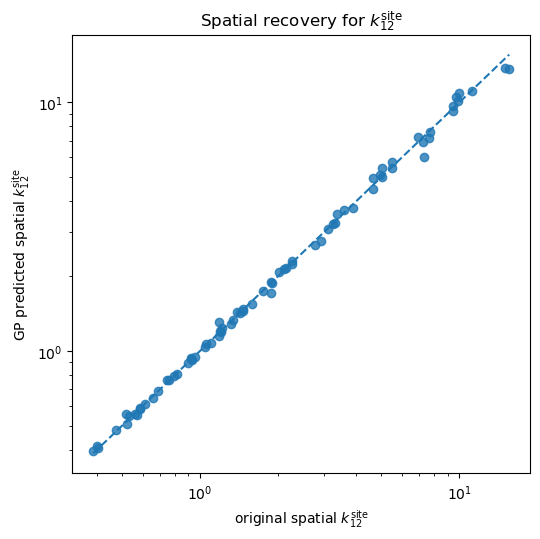

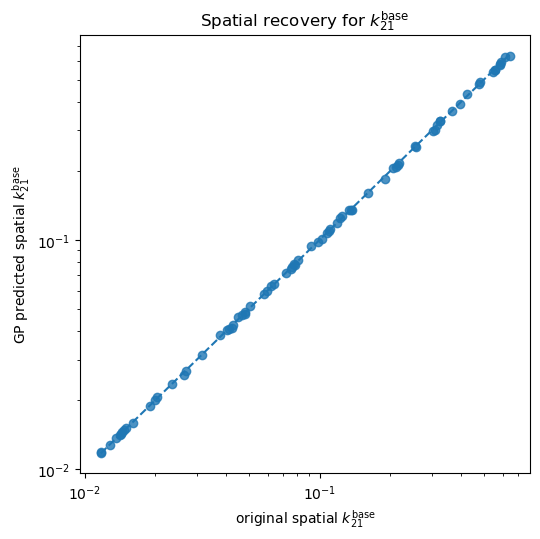

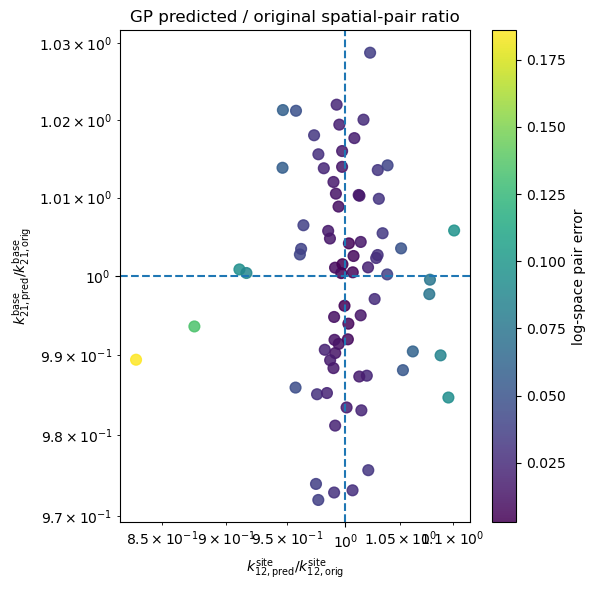

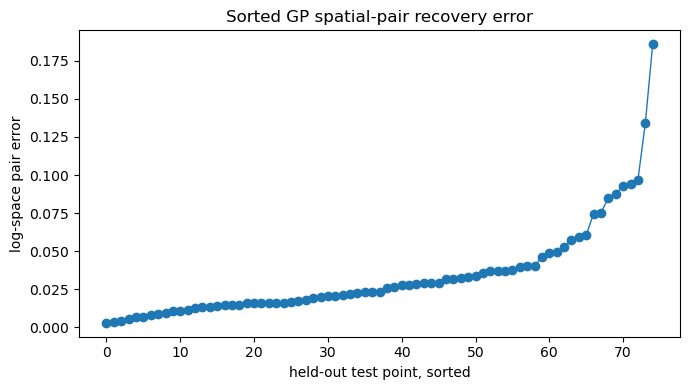


Worst 5 held-out spatial recovery cases
pair error: 0.18591295142968772
mapped population input:
  k12_pop = 12.297506072165987
  k21_pop = 0.024761736597918766
original spatial:
  k12_site = 7.287411005727991
  k21_base = 0.014354811752051892
GP predicted spatial:
  k12_site = 6.052904578453983
  k21_base = 0.014203346518198885
ratio predicted/original:
  [0.83059739 0.98944847]
pair error: 0.13400179872488488
mapped population input:
  k12_pop = 25.55806213189117
  k21_pop = 0.027648658508673797
original spatial:
  k12_site = 15.557081297672882
  k21_base = 0.016001379059846558
GP predicted spatial:
  k12_site = 13.608118867308058
  k21_base = 0.015899448993861025
ratio predicted/original:
  [0.87472185 0.99362992]
pair error: 0.09677971100094988
mapped population input:
  k12_pop = 3.109043541433396
  k21_pop = 0.026352518095794544
original spatial:
  k12_site = 1.1819504372391423
  k21_base = 0.01498081068556787
GP predicted spatial:
  k12_site = 1.30183322994697
  k21_base = 0.01

In [8]:
# ============================================================

original_spatial = np.exp(Y_test)
predicted_spatial = np.exp(Y_pred)

ratio = predicted_spatial / original_spatial
pair_err = np.sqrt(np.sum((Y_pred - Y_test)**2, axis=1))

# parity plots
labels = [
    r"$k_{12}^{\mathrm{site}}$",
    r"$k_{21}^{\mathrm{base}}$",
]

for j, label in enumerate(labels):
    x = original_spatial[:, j]
    y = predicted_spatial[:, j]

    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(x, y, alpha=0.8)
    plt.plot([lo, hi], [lo, hi], "--", linewidth=1.5)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(f"original spatial {label}")
    plt.ylabel(f"GP predicted spatial {label}")
    plt.title(f"Spatial recovery for {label}")
    plt.tight_layout()
    plt.show()


# ratio-pair plot
plt.figure(figsize=(6, 6))

sc = plt.scatter(
    ratio[:, 0],
    ratio[:, 1],
    c=pair_err,
    s=60,
    alpha=0.85,
)

plt.axvline(1.0, linestyle="--", linewidth=1.5)
plt.axhline(1.0, linestyle="--", linewidth=1.5)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$k_{12,\mathrm{pred}}^{\mathrm{site}} / k_{12,\mathrm{orig}}^{\mathrm{site}}$")
plt.ylabel(r"$k_{21,\mathrm{pred}}^{\mathrm{base}} / k_{21,\mathrm{orig}}^{\mathrm{base}}$")
plt.title("GP predicted / original spatial-pair ratio")
plt.colorbar(sc, label="log-space pair error")
plt.tight_layout()
plt.show()


# sorted pair error
plt.figure(figsize=(7, 4))
plt.plot(np.sort(pair_err), marker="o", linewidth=1)
plt.xlabel("held-out test point, sorted")
plt.ylabel("log-space pair error")
plt.title("Sorted GP spatial-pair recovery error")
plt.tight_layout()
plt.show()


# print worst cases
worst = np.argsort(pair_err)[-5:][::-1]

print()
print("Worst 5 held-out spatial recovery cases")
for idx in worst:
    print("=" * 60)
    print("pair error:", pair_err[idx])
    print("mapped population input:")
    print("  k12_pop =", np.exp(X_test[idx, 0]))
    print("  k21_pop =", np.exp(X_test[idx, 1]))
    print("original spatial:")
    print("  k12_site =", original_spatial[idx, 0])
    print("  k21_base =", original_spatial[idx, 1])
    print("GP predicted spatial:")
    print("  k12_site =", predicted_spatial[idx, 0])
    print("  k21_base =", predicted_spatial[idx, 1])
    print("ratio predicted/original:")
    print(" ", ratio[idx])

In [9]:
# ============================================================

MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)

gp_module = {
    "model": gp_model,
    "model_name": "gp_module",
    "model_type": "MultiOutputRegressor(GaussianProcessRegressor)",

    "input_space": "log_population",
    "output_space": "log_spatial",
    "input_names": ["k12_pop", "k21_pop"],
    "output_names": ["k12_site", "k21_base"],

    # backward-compatible aliases, in case old notebooks expect these names
    "input_aliases": ["k12_ctmc", "k21_ctmc"],

    "fixed_spatial_rates": {
        "init_bind": INIT_BIND,
        "k_det_1": K_DET_1,
    },

    "spatial_sampling_bounds": {
        "k12_site": [K12_SITE_MIN, K12_SITE_MAX],
        "k21_base": [K21_BASE_MIN, K21_BASE_MAX],
    },

    "population_filter_bounds": {
        "k12_pop": [K12_POP_MIN, K12_POP_MAX],
        "k21_pop": [K21_POP_MIN, K21_POP_MAX],
    },

    "training_info": {
        "n_good": int(len(df)),
        "n_spatial_reps": int(N_SPATIAL_REPS),
        "k12_map_error_max": float(K12_MAP_ERROR_MAX),
        "mean_pair_error": float(np.mean(pair_err)),
        "median_pair_error": float(np.median(pair_err)),
        "max_pair_error": float(np.max(pair_err)),
    },
}

MODEL_PATH = MODEL_DIR / "gp_module.joblib"
joblib.dump(gp_module, MODEL_PATH)

print()
print("Saved GP module to:", MODEL_PATH.resolve())


Saved GP module to: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\saved_models\gp_module.joblib
